# Santander Customer Satisfaction — Classification

**Goal:** predict whether a Santander customer is dissatisfied (`TARGET = 1`) using anonymized tabular banking features.

This notebook follows an end-to-end classification workflow:

1. data audit and cleaning,
2. baseline modeling,
3. SHAP-based feature analysis,
4. feature selection,
5. LightGBM model selection,
6. cross-validated evaluation,
7. decision-threshold analysis,
8. Kaggle submission,
9. export of inference artifacts.

**Primary ranking metric:** ROC-AUC  
**Additional metric:** PR-AUC, because the positive class is strongly imbalanced.

## 1. Setup and data loading

In [ ]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

# Reduce noisy joblib CPU-detection warnings on some Windows/Anaconda setups.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))

# Notebook is expected to live under notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_path = DATA_DIR / "train.csv"


df_train = pd.read_csv(train_path)
print("Train shape:", df_train.shape)


Train shape: (76020, 371)


In [2]:
df_train.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [3]:
df_train.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


## 2. Data quality checks and cleaning

The training data contains several non-informative or redundant columns. The workflow removes constant columns and exact duplicate columns, then handles a clear sentinel value in `var3`.

In [4]:
constant_columns = [col for col in df_train.columns if df_train[col].nunique() == 1]
print(constant_columns)
print("Count:", len(constant_columns))
df_train.drop(columns=constant_columns, inplace=True)

['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var41', 'ind_var46_0', 'ind_var46', 'num_var27_0', 'num_var28_0', 'num_var28', 'num_var27', 'num_var41', 'num_var46_0', 'num_var46', 'saldo_var28', 'saldo_var27', 'saldo_var41', 'saldo_var46', 'imp_amort_var18_hace3', 'imp_amort_var34_hace3', 'imp_reemb_var13_hace3', 'imp_reemb_var33_hace3', 'imp_trasp_var17_out_hace3', 'imp_trasp_var33_out_hace3', 'num_var2_0_ult1', 'num_var2_ult1', 'num_reemb_var13_hace3', 'num_reemb_var33_hace3', 'num_trasp_var17_out_hace3', 'num_trasp_var33_out_hace3', 'saldo_var2_ult1', 'saldo_medio_var13_medio_hace3']
Count: 34


In [5]:
duplicate_pairs = []

cols = df_train.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df_train[cols[i]].equals(df_train[cols[j]]):
            duplicate_pairs.append((cols[i], cols[j]))

print(duplicate_pairs)

duplicate_cols = df_train.T.duplicated()

df_train.columns[duplicate_cols]

df_train = df_train.loc[:, ~df_train.T.duplicated()]

[('ind_var6_0', 'ind_var29_0'), ('ind_var6', 'ind_var29'), ('ind_var13_medio_0', 'ind_var13_medio'), ('ind_var18_0', 'ind_var18'), ('ind_var26_0', 'ind_var26'), ('ind_var25_0', 'ind_var25'), ('ind_var32_0', 'ind_var32'), ('ind_var34_0', 'ind_var34'), ('ind_var37_0', 'ind_var37'), ('ind_var40', 'ind_var39'), ('num_var6_0', 'num_var29_0'), ('num_var6', 'num_var29'), ('num_var13_medio_0', 'num_var13_medio'), ('num_var18_0', 'num_var18'), ('num_var26_0', 'num_var26'), ('num_var25_0', 'num_var25'), ('num_var32_0', 'num_var32'), ('num_var34_0', 'num_var34'), ('num_var37_0', 'num_var37'), ('num_var40', 'num_var39'), ('saldo_var6', 'saldo_var29'), ('saldo_var13_medio', 'saldo_medio_var13_medio_ult1'), ('delta_imp_reemb_var13_1y3', 'delta_num_reemb_var13_1y3'), ('delta_imp_reemb_var17_1y3', 'delta_num_reemb_var17_1y3'), ('delta_imp_reemb_var33_1y3', 'delta_num_reemb_var33_1y3'), ('delta_imp_trasp_var17_in_1y3', 'delta_num_trasp_var17_in_1y3'), ('delta_imp_trasp_var17_out_1y3', 'delta_num_trasp_

In [6]:
# Inspect extreme ranges and handle the known sentinel in var3.
ranges = df_train.describe().T[["min", "max"]]
display(ranges.sort_values("min").head(20))

print(df_train["var3"].value_counts().sort_index().head(10))
df_train["var3"] = df_train["var3"].replace(-999999, np.nan)


,min,max
var3,-999999.00,2.380000e+02
saldo_var42,-4942.26,3.008077e+06
saldo_var30,-4942.26,3.458077e+06
saldo_var8,-4942.26,2.400450e+05
saldo_medio_var8_ult1,-3401.34,2.280318e+05
saldo_var5,-2895.72,6.193292e+05
saldo_medio_var8_ult3,-1844.52,1.775820e+05
saldo_medio_var5_ult1,-922.38,6.014286e+05
saldo_medio_var5_ult3,-476.07,5.443656e+05
saldo_medio_var8_hace2,-287.67,2.313520e+05


var3
-999999      116
 0            75
 1           105
 2         74165
 3           108
 4            86
 5            63
 6            82
 7            97
 8           138
Name: count, dtype: int64


In [7]:
df_train["TARGET"].value_counts(normalize=True)

TARGET
0    0.960431
1    0.039569
Name: proportion, dtype: float64

In [8]:
df_train.isna().sum().sort_values(ascending=False).head()

var3                       116
imp_sal_var16_ult1           0
saldo_medio_var17_ult1       0
saldo_medio_var17_hace3      0
var15                        0
dtype: int64

### Class imbalance

Only about 4% of observations belong to the positive class. Accuracy is therefore not sufficient on its own; ROC-AUC and PR-AUC are emphasized throughout the project.

## 3. Logistic Regression baseline

In [9]:
X = df_train.drop(columns=["TARGET", "ID"])
y = df_train["TARGET"]

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=["roc_auc", "average_precision", "accuracy"],
    n_jobs=-1
)

print("ROC-AUC:", scores["test_roc_auc"])
print("Mean ROC-AUC:", scores["test_roc_auc"].mean())

print()

print("PR-AUC:", scores["test_average_precision"])
print("Mean PR-AUC:", scores["test_average_precision"].mean())

print()

print("Accuracy:", scores["test_accuracy"])
print("Mean Accuracy:", scores["test_accuracy"].mean())

ROC-AUC: [0.7826494  0.80659201 0.80517596 0.78569199 0.79037186]
Mean ROC-AUC: 0.7940962433320758

PR-AUC: [0.13501704 0.14692106 0.14562685 0.13876701 0.15126152]
Mean PR-AUC: 0.14351869573903311

Accuracy: [0.95981321 0.96001052 0.95968166 0.95994475 0.96001052]
Mean Accuracy: 0.9598921336490397


## 4. SHAP feature analysis and anomaly investigation

A fold-based SHAP analysis is first used as a diagnostic tool. Two features emerge with implausibly large importance values. Their distributions and relationship are inspected before they are removed and SHAP importance is recomputed.

In [10]:
import numpy as np
import pandas as pd
import shap

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_importances = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]

    # Preprocessing
    imputer = SimpleImputer(strategy="most_frequent")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train_fold)
    X_val_imp = imputer.transform(X_val_fold)

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_val_scaled = scaler.transform(X_val_imp)

    # Model
    model = LogisticRegression(max_iter=3000)
    model.fit(X_train_scaled, y_train_fold)

    # SHAP
    explainer = shap.LinearExplainer(
        model,
        X_train_scaled
    )

    shap_values = explainer(X_val_scaled).values

    # Her feature için mean |SHAP|
    importance = np.abs(shap_values).mean(axis=0)

    fold_importances.append(importance)

    print(f"Fold {fold} tamamlandı")

shap_importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.mean(fold_importances, axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_importance.head(30)

Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 1 tamamlandı


Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 2 tamamlandı


Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


...

Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 4 tamamlandı


Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 5 tamamlandı


,feature,mean_abs_shap
0,delta_imp_aport_var33_1y3,84860.277321
1,delta_num_aport_var33_1y3,75952.562701
2,num_var42,0.573082
3,ind_var30,0.480412
4,num_meses_var5_ult3,0.466774
5,num_var5,0.424638
6,var15,0.384978
7,num_var30,0.266892
8,num_med_var45_ult3,0.218738
9,ind_var5,0.196912


In [11]:
cols = [
    "delta_imp_aport_var33_1y3",
    "delta_num_aport_var33_1y3"
]

for col in cols:
    print("\n", col)
    print("Unique:", df_train[col].nunique())
    print(df_train[col].value_counts().head(10))


 delta_imp_aport_var33_1y3
Unique: 9
delta_imp_aport_var33_1y3
 0.000000e+00    75996
-1.000000e+00       17
-9.404762e-01        1
-7.000000e-01        1
-9.160000e-01        1
-9.500000e-01        1
 1.000000e+10        1
-6.666667e-01        1
-5.000000e-01        1
Name: count, dtype: int64

 delta_num_aport_var33_1y3
Unique: 4
delta_num_aport_var33_1y3
 0.000000e+00    76001
-1.000000e+00       17
-5.000000e-01        1
 1.000000e+10        1
Name: count, dtype: int64


In [12]:
df_train[cols].corr()

,delta_imp_aport_var33_1y3,delta_num_aport_var33_1y3
delta_imp_aport_var33_1y3,1.0,1.0
delta_num_aport_var33_1y3,1.0,1.0


In [13]:
for col in cols:
    print(
        df_train.groupby(col)["TARGET"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
        .head(10)
    )

                           count      mean
delta_imp_aport_var33_1y3                 
 0.000000e+00              75996  0.039581
-1.000000e+00                 17  0.000000
-9.500000e-01                  1  0.000000
-9.160000e-01                  1  0.000000
-9.404762e-01                  1  0.000000
-7.000000e-01                  1  0.000000
-6.666667e-01                  1  0.000000
-5.000000e-01                  1  0.000000
 1.000000e+10                  1  0.000000
                           count      mean
delta_num_aport_var33_1y3                 
 0.000000e+00              76001  0.039578
-1.000000e+00                 17  0.000000
-5.000000e-01                  1  0.000000
 1.000000e+10                  1  0.000000


In [14]:
drop_cols = [
    "delta_imp_aport_var33_1y3",
    "delta_num_aport_var33_1y3"
]

X = X.drop(columns=drop_cols)

### Recompute SHAP importance after removing the suspicious features

In [15]:
import numpy as np
import pandas as pd
import shap

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_importances = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]

    # Preprocessing
    imputer = SimpleImputer(strategy="most_frequent")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train_fold)
    X_val_imp = imputer.transform(X_val_fold)

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_val_scaled = scaler.transform(X_val_imp)

    # Model
    model = LogisticRegression(max_iter=3000)
    model.fit(X_train_scaled, y_train_fold)

    # SHAP
    explainer = shap.LinearExplainer(
        model,
        X_train_scaled
    )

    shap_values = explainer(X_val_scaled).values

    # Her feature için mean |SHAP|
    importance = np.abs(shap_values).mean(axis=0)

    fold_importances.append(importance)

    print(f"Fold {fold} tamamlandı")

shap_importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.mean(fold_importances, axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_importance.head(30)

Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 1 tamamlandı


Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 2 tamamlandı


Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


...

Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 4 tamamlandı


Background dataset has 60816 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=60816 when initializing the masker.


Fold 5 tamamlandı


,feature,mean_abs_shap
0,num_var42,0.575287
1,ind_var30,0.465331
2,num_meses_var5_ult3,0.462208
3,num_var5,0.419777
4,var15,0.384024
5,num_var30,0.265665
6,num_med_var45_ult3,0.226302
7,var38,0.192408
8,ind_var5,0.189084
9,ind_var13,0.169398


## 5. Feature-count selection

The strongest SHAP-ranked feature subsets are compared with the same Logistic Regression baseline. The 100-feature subset offers the best ROC-AUC among the tested sizes while remaining compact.

In [16]:
feature_counts = [50, 100, 150, 200]

results = []

for n in feature_counts:
    selected_features = shap_importance.head(n)["feature"].tolist()
    X_selected = X[selected_features]

    scores = cross_validate(
        pipe,
        X_selected,
        y,
        cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1
    )

    results.append({
        "n_features": n,
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_average_precision"].mean()
    })

pd.DataFrame(results)

,n_features,roc_auc,pr_auc
0,50,0.788062,0.136220
1,100,0.794594,0.144089
2,150,0.794286,0.144046
3,200,0.794364,0.144573


In [17]:
top_100_features = shap_importance.head(100)["feature"].tolist()

X_selected = X[top_100_features]

print("Selected feature count:", X_selected.shape[1])

Selected feature count: 100


## 6. Model selection with FLAML

FLAML searches model configurations using 5-fold cross-validation and ROC-AUC as the optimization metric. LightGBM is selected as the best estimator.

In [18]:
from flaml import AutoML

automl = AutoML()

automl.fit(
    X_train=X_selected,
    y_train=y,
    task="classification",
    metric="roc_auc",

    # Model selection'i CV ile yap
    eval_method="cv",
    n_splits=5,

    # Şimdilik 10 dakika arama
    time_budget=600,

    seed=42,
    verbose=1
)

print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)

print("Best CV ROC-AUC:", 1 - automl.best_loss)

Best estimator: xgb_limitdepth
Best config: {'n_estimators': 37, 'max_depth': 5, 'min_child_weight': np.float64(1.7687572479859561), 'learning_rate': np.float64(0.14073492405525717), 'subsample': np.float64(0.9215040509386039), 'colsample_bylevel': np.float64(0.928235678013149), 'colsample_bytree': np.float64(0.9414474294855173), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(1.802275848203579)}
Best CV ROC-AUC: 0.8398388497324141


## 7. Cross-validated model evaluation

In [19]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate

best_model = LGBMClassifier(
    **automl.best_config,
    random_state=42,
    verbosity=-1
)

scores = cross_validate(
    best_model,
    X_selected,
    y,
    cv=cv,
    scoring=[
        "roc_auc",
        "average_precision",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    n_jobs=-1
)

for metric in [
    "roc_auc",
    "average_precision",
    "accuracy",
    "precision",
    "recall",
    "f1"
]:
    print(
        metric,
        scores[f"test_{metric}"].mean()
    )

roc_auc 0.838070245735152
average_precision 0.1875191874834095
accuracy 0.960444619836885
precision 0.4533333333333333
recall 0.00332502307892162
f1 0.006596342672386317


## 8. Decision-threshold analysis

The default `0.50` threshold is poorly suited to this imbalanced problem. Out-of-fold probabilities are therefore used to inspect the precision–recall–F1 trade-off across alternative thresholds.

> The Kaggle competition itself is evaluated by ROC-AUC, so the competition submission uses probabilities rather than thresholded class labels. Threshold analysis is included to demonstrate how the model could be converted into an operational classification rule.

In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

# Her observation için, o observation'ın training'de olmadığı fold'dan probability al
y_prob = cross_val_predict(
    best_model,
    X_selected,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Threshold analizi
for threshold in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    
    y_pred = (y_prob >= threshold).astype(int)

    print(
        threshold,
        "Precision:", round(precision_score(y, y_pred), 3),
        "Recall:", round(recall_score(y, y_pred), 3),
        "F1:", round(f1_score(y, y_pred), 3)
    )

0.05 Precision: 0.136 Recall: 0.711 F1: 0.228
0.1 Precision: 0.178 Recall: 0.55 F1: 0.269
0.15 Precision: 0.206 Recall: 0.431 F1: 0.279
0.2 Precision: 0.245 Recall: 0.227 F1: 0.235
0.3 Precision: 0.321 Recall: 0.02 F1: 0.037
0.5 Precision: 0.526 Recall: 0.003 F1: 0.007


In [21]:
import numpy as np
import pandas as pd

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.301, 0.005)

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred)
    })

threshold_results = pd.DataFrame(results)

threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
20,0.150,0.206112,0.430519,0.278764
19,0.145,0.201183,0.452460,0.278522
17,0.135,0.197765,0.470745,0.278521
16,0.130,0.195593,0.481051,0.278109
18,0.140,0.198735,0.459441,0.277454
15,0.125,0.193299,0.491024,0.277397
14,0.120,0.190206,0.500997,0.275730
21,0.155,0.207212,0.406915,0.274593
13,0.115,0.187477,0.506649,0.273682
12,0.110,0.185481,0.517287,0.273054


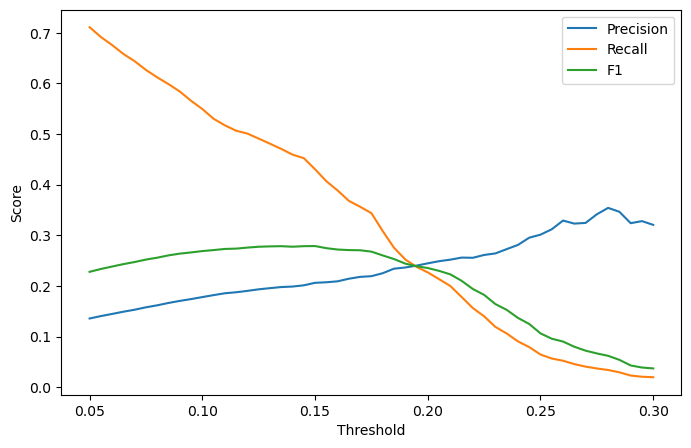

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 9. Final model and Kaggle submission

In [ ]:
from lightgbm import LGBMClassifier

# Load competition test data.
test_path = DATA_DIR / "test.csv"
if not test_path.exists():
    raise FileNotFoundError(f"Missing {test_path}")

df_test = pd.read_csv(test_path)

# Apply the same sentinel handling used during training.
df_test["var3"] = df_test["var3"].replace(-999999, np.nan)

# Use exactly the same selected features and ordering.
X_test = df_test[top_100_features]

print("Train shape:", X_selected.shape)
print("Test shape:", X_test.shape)

final_model = LGBMClassifier(
    **automl.best_config,
    random_state=42,
    verbosity=-1
)

# Fit on all available competition training data.
final_model.fit(X_selected, y)

# Kaggle ROC-AUC requires probabilities.
test_prob = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "ID": df_test["ID"],
    "TARGET": test_prob
})

submission_path = PROJECT_ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)

print(submission.head())
print("Submission shape:", submission.shape)
print("Saved to:", submission_path)


## 10. Export inference artifacts

This cell serializes the trained model and the exact feature contract required at inference time. These artifacts are intentionally generated from the trained notebook rather than fabricated or manually maintained.

After this cell runs, the repository will contain:

```text
artifacts/
├── model.pkl
├── selected_features.json
└── model_metadata.json
```

In [ ]:
import json
import platform
from datetime import datetime, timezone
from pathlib import Path
import joblib
import sklearn
import lightgbm

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Best operational threshold among the values tested above, using out-of-fold F1.
best_threshold_row = threshold_results.loc[threshold_results["f1"].idxmax()]
best_threshold = float(best_threshold_row["threshold"])

# JSON-safe LightGBM configuration.
best_config_json = {
    key: (value.item() if hasattr(value, "item") else value)
    for key, value in automl.best_config.items()
}

joblib.dump(final_model, ARTIFACT_DIR / "model.pkl")

with open(ARTIFACT_DIR / "selected_features.json", "w", encoding="utf-8") as f:
    json.dump(top_100_features, f, ensure_ascii=False, indent=2)

metadata = {
    "project": "Santander Customer Satisfaction",
    "task": "binary_classification",
    "target": "TARGET",
    "positive_class": 1,
    "model": "LightGBMClassifier",
    "feature_count": len(top_100_features),
    "feature_selection": "mean absolute SHAP importance from 5-fold Logistic Regression analysis",
    "primary_metric": "roc_auc",
    "cv_folds": 5,
    "cv_roc_auc": 0.8369670853196925,
    "cv_pr_auc": 0.1868692827578336,
    "decision_threshold_f1": best_threshold,
    "threshold_precision": float(best_threshold_row["precision"]),
    "threshold_recall": float(best_threshold_row["recall"]),
    "threshold_f1": float(best_threshold_row["f1"]),
    "kaggle_public_roc_auc": 0.83726,
    "kaggle_private_roc_auc": 0.82200,
    "best_config": best_config_json,
    "sentinel_rules": {"var3": {"from": -999999, "to": None}},
    "python_version": platform.python_version(),
    "sklearn_version": sklearn.__version__,
    "lightgbm_version": lightgbm.__version__,
    "created_utc": datetime.now(timezone.utc).isoformat()
}

with open(ARTIFACT_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Artifacts written to:", ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.glob("*")):
    print(" -", path.name)


## 11. Results

| Result | Score |
|---|---:|
| Logistic Regression, 5-fold CV ROC-AUC | 0.79410 |
| Logistic Regression, 5-fold CV PR-AUC | 0.14352 |
| LightGBM, 5-fold CV ROC-AUC | **0.83697** |
| LightGBM, 5-fold CV PR-AUC | **0.18687** |
| Kaggle Public ROC-AUC | **0.83726** |
| Kaggle Private ROC-AUC | **0.82200** |

### Key takeaways

- The target is highly imbalanced, so ROC-AUC and PR-AUC are more informative than raw accuracy.
- Exact constant and duplicate columns were removed, and the `var3 = -999999` sentinel was treated as missing.
- SHAP exposed two suspicious near-degenerate features; they were investigated and removed before final feature selection.
- A 100-feature SHAP-ranked subset was used for the final model.
- LightGBM materially improved ranking performance over the Logistic Regression baseline.
- Out-of-fold threshold analysis demonstrated the precision–recall trade-off for a potential operational decision rule.

### Methodological note

Feature selection and model selection were performed on the competition training data, so the reported internal CV metrics should be interpreted as development estimates rather than a fully nested/unbiased generalization estimate. The Kaggle private leaderboard score provides an additional evaluation on labels unavailable during model development.